In [43]:
import numpy as np
import pandas as pd

# Load the saved test data, weights, and bias
# Using allow_pickle=True to safely handle the numpy objects
X_test = np.load('X_test.npy', allow_pickle=True)
y_test = np.load('y_test.npy', allow_pickle=True)
w = np.load('w.npy', allow_pickle=True)
b = np.load('b.npy', allow_pickle=True)

print("Files loaded successfully!")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Weights shape: {w.shape}")
print(f"Bias value: {b}")

Files loaded successfully!
X_test shape: (193, 28)
y_test shape: (193, 1)
Weights shape: (28, 1)
Bias value: -0.4591120645341018


In [45]:
import numpy as np

unique_classes, counts = np.unique(y_test, return_counts=True)
class_distribution = dict(zip(unique_classes, counts))
print("Test set class distribution:", class_distribution)

# Calculate baseline accuracy of a dummy model that always predicts the majority class
majority_class_count = np.max(counts)
baseline_accuracy = (majority_class_count / len(y_test)) * 100
print(f"Naive Baseline Accuracy: {baseline_accuracy:.2f}%")

Test set class distribution: {np.int64(0): np.int64(159), np.int64(1): np.int64(34)}
Naive Baseline Accuracy: 82.38%


In [48]:
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix

thresholds = np.linspace(0.01, 0.99, 100)
best_threshold = 0.5
best_f1 = 0

for th in thresholds:
    y_pred_temp = (y_pred_prob >= th).astype(int)
    score = f1_score(y_test, y_pred_temp, zero_division=0)
    if score > best_f1:
        best_f1 = score
        best_threshold = th

print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"Best F1-Score: {best_f1:.4f}")

# Evaluate with the new threshold
y_pred_optimized = (y_pred_prob >= best_threshold).astype(int)
print("New Confusion Matrix:\n", confusion_matrix(y_test, y_pred_optimized))

Optimal Threshold: 0.1684
Best F1-Score: 0.4320
New Confusion Matrix:
 [[95 64]
 [ 7 27]]


Confusion Matrix:
 [[159   0]
 [ 32   2]]


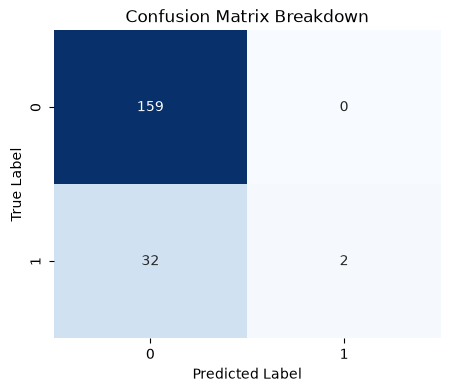

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Convert predicted probabilities into binary predictions (0 or 1) using a 0.5 threshold
y_pred_binary = (y_pred_prob >= 0.5).astype(int)

# 2. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_binary)
print("Confusion Matrix:\n", cm)

# 3. Visualize the breakdown
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Breakdown')
plt.show()